# 06 — Spatial Kinship & Dispersal

Map identified kin pairs spatially and estimate dispersal distances.

**Inputs**: `data/kin_pairs.csv`, `data/master_metadata.csv`
**Output**: `results/fig_kin_spatial.png`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
kin_pairs = pd.read_csv('../data/kin_pairs.csv')
meta = pd.read_csv('../data/master_metadata.csv')
print(f'Kin pairs: {len(kin_pairs)}')
print(f'By relationship: {kin_pairs["relationship"].value_counts().to_dict()}')

Kin pairs: 2153
By relationship: {'3rd': 1542, '2nd': 607, 'FS': 4}


In [3]:
def haversine(lat1, lon1, lat2, lon2):
    """Haversine distance in km."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Get GPS for each sample
gps = meta[['sample_id', 'latitude', 'longitude']].drop_duplicates(subset='sample_id').dropna()
gps_dict = gps.set_index('sample_id')[['latitude', 'longitude']].to_dict('index')

# Compute distances for kin pairs
distances = []
for _, row in kin_pairs.iterrows():
    s1, s2 = row['sample_1'], row['sample_2']
    if s1 in gps_dict and s2 in gps_dict:
        d = haversine(gps_dict[s1]['latitude'], gps_dict[s1]['longitude'],
                      gps_dict[s2]['latitude'], gps_dict[s2]['longitude'])
        distances.append(d)
    else:
        distances.append(np.nan)

kin_pairs['distance_km'] = distances
print(f'Pairs with GPS data: {kin_pairs["distance_km"].notna().sum()}')

Pairs with GPS data: 2148


In [4]:
# Dispersal distances by relationship category
print('Geographic distance (km) by relationship category:')
for rel in ['PO', 'FS', '2nd', '3rd']:
    subset = kin_pairs[kin_pairs['relationship'] == rel]['distance_km'].dropna()
    if len(subset) > 0:
        print(f'  {rel} (n={len(subset)}): mean={subset.mean():.2f}, median={subset.median():.2f}, '
              f'min={subset.min():.2f}, max={subset.max():.2f} km')

Geographic distance (km) by relationship category:
  FS (n=4): mean=1.04, median=0.99, min=0.17, max=2.00 km
  2nd (n=606): mean=2.05, median=2.01, min=0.00, max=4.56 km
  3rd (n=1538): mean=1.99, median=2.12, min=0.00, max=4.56 km


In [5]:
# Generate null distribution: random pair distances
rng = np.random.default_rng(42)
gps_arr = gps[['latitude', 'longitude']].values
n_random = min(10000, len(gps) * (len(gps) - 1) // 2)

rand_dists = []
for _ in range(n_random):
    i, j = rng.choice(len(gps_arr), 2, replace=False)
    rand_dists.append(haversine(gps_arr[i, 0], gps_arr[i, 1], gps_arr[j, 0], gps_arr[j, 1]))
rand_dists = np.array(rand_dists)

print(f'Random pair distances: mean={rand_dists.mean():.2f}, median={np.median(rand_dists):.2f} km')

Random pair distances: mean=2.02, median=2.10 km


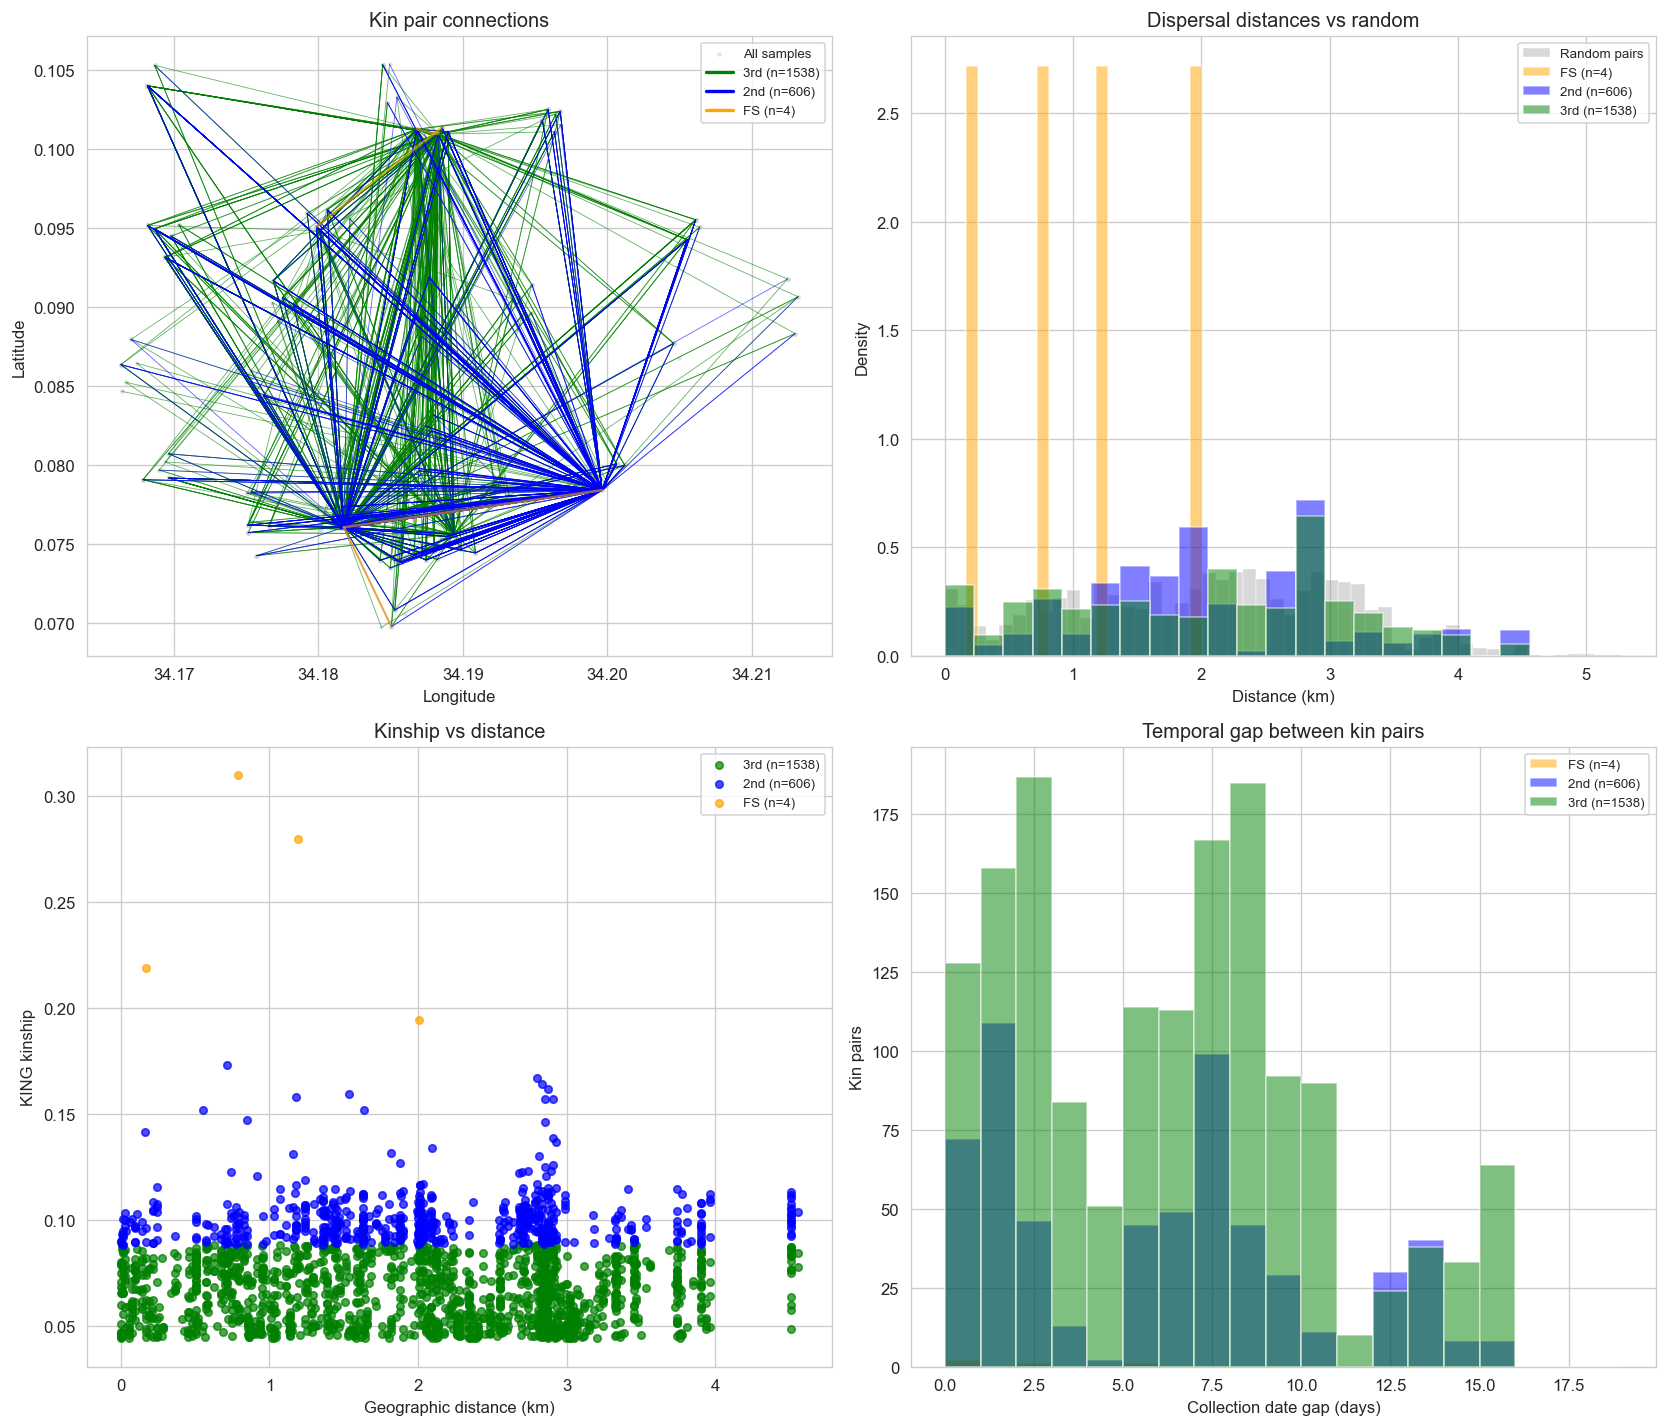

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Map with kin pair connections
ax = axes[0, 0]
ax.scatter(gps['longitude'], gps['latitude'], s=3, c='lightgrey', alpha=0.5, label='All samples')

colors = {'PO': 'red', 'FS': 'orange', '2nd': 'blue', '3rd': 'green'}
for rel in ['3rd', '2nd', 'FS', 'PO']:  # draw close kin last (on top)
    subset = kin_pairs[(kin_pairs['relationship'] == rel) & kin_pairs['distance_km'].notna()]
    if len(subset) == 0:
        continue
    for _, pair in subset.iterrows():
        if pair['sample_1'] in gps_dict and pair['sample_2'] in gps_dict:
            g1 = gps_dict[pair['sample_1']]
            g2 = gps_dict[pair['sample_2']]
            ax.plot([g1['longitude'], g2['longitude']], [g1['latitude'], g2['latitude']],
                    c=colors[rel], alpha=0.6, lw=1.5 if rel in ['PO', 'FS'] else 0.5)
    # Add to legend
    ax.plot([], [], c=colors[rel], label=f'{rel} (n={len(subset)})', lw=2)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Kin pair connections')
ax.legend(fontsize=8)

# 2. Distance distributions by category
ax = axes[0, 1]
ax.hist(rand_dists, bins=50, density=True, alpha=0.3, color='grey', label='Random pairs')
for rel in ['PO', 'FS', '2nd', '3rd']:
    subset = kin_pairs[kin_pairs['relationship'] == rel]['distance_km'].dropna()
    if len(subset) > 2:
        ax.hist(subset, bins=20, density=True, alpha=0.5, color=colors[rel], label=f'{rel} (n={len(subset)})')
    elif len(subset) > 0:
        for d in subset:
            ax.axvline(d, color=colors[rel], ls='--', label=f'{rel} ({d:.1f} km)')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Density')
ax.set_title('Dispersal distances vs random')
ax.legend(fontsize=8)

# 3. Kinship vs geographic distance
ax = axes[1, 0]
valid = kin_pairs.dropna(subset=['distance_km'])
if len(valid) > 0:
    for rel in ['3rd', '2nd', 'FS', 'PO']:
        subset = valid[valid['relationship'] == rel]
        if len(subset) > 0:
            ax.scatter(subset['distance_km'], subset['kinship'], s=20, c=colors[rel], 
                      label=f'{rel} (n={len(subset)})', alpha=0.7)
ax.set_xlabel('Geographic distance (km)')
ax.set_ylabel('KING kinship')
ax.set_title('Kinship vs distance')
ax.legend(fontsize=8)

# 4. Temporal patterns: collection date gap for kin pairs
ax = axes[1, 1]
date_cols_1 = [c for c in kin_pairs.columns if 'date' in c.lower() and '_1' in c]
date_cols_2 = [c for c in kin_pairs.columns if 'date' in c.lower() and '_2' in c]
if date_cols_1 and date_cols_2:
    kin_pairs['date_1'] = pd.to_datetime(kin_pairs[date_cols_1[0]], errors='coerce')
    kin_pairs['date_2'] = pd.to_datetime(kin_pairs[date_cols_2[0]], errors='coerce')
    kin_pairs['date_gap_days'] = (kin_pairs['date_1'] - kin_pairs['date_2']).dt.days.abs()
    
    for rel in ['PO', 'FS', '2nd', '3rd']:
        subset = kin_pairs[kin_pairs['relationship'] == rel]['date_gap_days'].dropna()
        if len(subset) > 0:
            ax.hist(subset, bins=range(0, 20), alpha=0.5, color=colors[rel], label=f'{rel} (n={len(subset)})')
    ax.set_xlabel('Collection date gap (days)')
    ax.set_ylabel('Kin pairs')
    ax.set_title('Temporal gap between kin pairs')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No date columns available', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('../results/fig_kin_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

## Dispersal kernel estimation

In [7]:
# If we have enough PO or FS pairs, estimate dispersal kernel
close_kin = kin_pairs[kin_pairs['relationship'].isin(['PO', 'FS'])]
close_dists = close_kin['distance_km'].dropna()

if len(close_dists) >= 3:
    from scipy.stats import expon, norm
    
    # Fit exponential and half-normal dispersal kernels
    exp_params = expon.fit(close_dists, floc=0)
    norm_params = norm.fit(close_dists)
    
    print(f'Dispersal kernel estimates from {len(close_dists)} close-kin pairs:')
    print(f'  Exponential: mean dispersal = {exp_params[1]:.2f} km')
    print(f'  Half-normal: sigma = {norm_params[1]:.2f} km')
    print(f'  Observed: mean = {close_dists.mean():.2f}, median = {close_dists.median():.2f} km')
else:
    print(f'Only {len(close_dists)} close-kin pairs with GPS — insufficient for kernel estimation.')
    print('Reporting raw distances instead.')
    if len(close_dists) > 0:
        print(f'  Distances: {close_dists.values}')

Dispersal kernel estimates from 4 close-kin pairs:
  Exponential: mean dispersal = 1.04 km
  Half-normal: sigma = 0.67 km
  Observed: mean = 1.04, median = 0.99 km


In [8]:
# Summary table
print('\n=== Spatial Kinship Summary ===')
for rel in ['PO', 'FS', '2nd', '3rd']:
    subset = kin_pairs[kin_pairs['relationship'] == rel]
    dists = subset['distance_km'].dropna()
    if len(subset) > 0:
        print(f'{rel}: {len(subset)} pairs, {len(dists)} with GPS, '
              f'mean dist = {dists.mean():.2f} km' if len(dists) > 0 else f'{rel}: {len(subset)} pairs, no GPS')


=== Spatial Kinship Summary ===
FS: 4 pairs, 4 with GPS, mean dist = 1.04 km
2nd: 607 pairs, 606 with GPS, mean dist = 2.05 km
3rd: 1542 pairs, 1538 with GPS, mean dist = 1.99 km
